# Drawing the gold set

This notebook draws the 30 figures of the gold set from the May 2026 bioRxiv dump. For each figure it saves the image as a PNG and starts an annotation file that holds the article details and the caption. The annotation itself (figure type, the text printed in the image, and the entities) is filled in  `annotate_gold_set.ipynb`, following `gold_set/guidelines.md`.

 Keep the Cell Biology preprints released under CC BY 4.0 or CC0 1.0, and only the latest version of each.


In [1]:
import hashlib
import json
import random
import re
import time
import zipfile
import xml.etree.ElementTree as ET
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

from bfg.ingest.jats import parse_jats

# The package root is the first folder above this notebook with a pyproject.toml
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
MECA_DIR = ROOT / 'data' / 'May_2026'
GOLD_DIR = ROOT / 'gold_set'
IMAGE_DIR = GOLD_DIR / 'images'
ANNOTATION_DIR = GOLD_DIR / 'annotations'
for folder in (IMAGE_DIR, ANNOTATION_DIR):
    folder.mkdir(parents=True, exist_ok=True)

SUBJECT = 'Cell Biology'
LICENCES = {   # part of the licence URL in the JATS XML, and the name we record
    'creativecommons.org/licenses/by/4.0': 'CC BY 4.0',
    'creativecommons.org/publicdomain/zero/1.0': 'CC0 1.0',
}
MAIN_FIGURE = re.compile(r'fig\d+')   # fig1, fig2, ... supplementary figures have ids like figS1
SAMPLE_SIZE = 30
SEED = 20260928   # the date the sample was drawn

print('archives :', MECA_DIR.relative_to(ROOT))
print('gold set :', GOLD_DIR.relative_to(ROOT))

archives : data/May_2026
gold set : gold_set


## 1. Read every archive

A `.meca` file is a ZIP archive. Its `manifest.xml` points to the article's JATS XML, which holds the title, the authors, the subject collection, the licence and the figure captions. The figure images sit next to the XML as TIFF files.

`read_archive` reads the manifest and the XML out of one archive and notes, for each figure, whether its image is in the archive. The captions come from the pipeline's own `parse_jats`, so the caption stored with a gold figure is exactly the one the pipeline reads. The scan of all 7,132 archives takes well under a minute.

In [2]:
MECA_NS = '{http://manuscriptexchange.org}'
XLINK_HREF = '{http://www.w3.org/1999/xlink}href'


def text_of(node):
    """All the text inside an XML element, with the whitespace tidied up."""
    return ' '.join(''.join(node.itertext()).split()) if node is not None else ''


def licence_name(url):
    """Short name of a licence we can share images under, or None for any other licence."""
    return next((name for part, name in LICENCES.items() if url and part in url), None)


def read_archive(path):
    """Article metadata and the list of figures in one .meca archive."""
    with zipfile.ZipFile(path) as zf:
        members = {Path(name).name for name in zf.namelist()}
        manifest = ET.fromstring(zf.read('manifest.xml'))
        item = next(i for i in manifest.iter(MECA_NS + 'item') if i.get('type') == 'article')
        xml_name = next(i.get('href') for i in item.iter(MECA_NS + 'instance')
                        if i.get('media-type') == 'application/xml')
        xml = zf.read(xml_name)

    meta = ET.fromstring(xml).find('front/article-meta')
    jats = parse_jats(BytesIO(xml))
    licence = meta.find('permissions/license')
    licence_url = licence.get(XLINK_HREF) if licence is not None else None
    preprint, version = re.fullmatch(r'(\d+)v(\d+)', item.get('id')).groups()
    return {
        'archive': path.name,
        'preprint': preprint,
        'version': int(version),
        'doi': meta.findtext("article-id[@pub-id-type='doi']"),
        'title': jats.title,
        'surnames': [text_of(c.find('name/surname')) for c in meta.iter('contrib')
                     if c.get('contrib-type') == 'author' and c.find('name/surname') is not None],
        'subjects': [text_of(s) for g in meta.iter('subj-group')
                     if g.get('subj-group-type') == 'hwp-journal-coll' for s in g.iter('subject')],
        'licence_url': licence_url,
        'licence': licence_name(licence_url),
        'figures': [{'fig_id': f.fig_id, 'label': f.label, 'caption': f.caption, 'href': f.href,
                     'has_image': bool(f.href) and Path(f.href).name in members}
                    for f in jats.figures],
    }


archives = sorted(MECA_DIR.glob('*.meca'))
start = time.time()
rows, failed = [], []
for path in archives:
    try:
        rows.append(read_archive(path))
    except Exception as err:   # report a broken archive and carry on
        failed.append((path.name, repr(err)))
articles = pd.DataFrame(rows)

# A hash of the archive names, so a later run can tell whether the folder has changed
fingerprint = hashlib.sha1('\n'.join(p.name for p in archives).encode('utf-8')).hexdigest()

print(f'{len(articles):,} of {len(archives):,} archives read in {time.time() - start:.0f} s, {len(failed)} failed')
print(f"{articles['figures'].map(len).sum():,} figures in total")
print('fingerprint:', fingerprint)

7,132 of 7,132 archives read in 32 s, 0 failed
54,418 figures in total
fingerprint: 826c2a14b1571f6e4b7dcd78585321aee0512f1a


## 2. Narrow the dump down to a pool

Four filters leave the pool that the sample is drawn from.

- **Subject.**  Cell Biology.
- **Licence.** CC BY 4.0 and CC0 1.0
- **Latest version.** Some preprints are in the dump more than once, for example as version 1 and version 2. Keeping the latest version.

In [3]:
def main_figures(figures):
    """The main figures of an article that have both an image and a caption."""
    return [f for f in figures if MAIN_FIGURE.fullmatch(f['fig_id']) and f['has_image'] and f['caption']]


def n_figures(df):
    return int(df['figures'].map(len).sum())


print('subject collections per preprint:', articles['subjects'].map(len).value_counts().to_dict())
cell_bio = articles[articles['subjects'].map(lambda s: SUBJECT in s)]
open_licence = cell_bio[cell_bio['licence'].notna()]
latest = open_licence.sort_values('version').groupby('preprint').tail(1)
pool = latest.assign(main=latest['figures'].map(main_figures))
pool = pool[pool['main'].map(len) > 0]

print(f'\nlicences in {SUBJECT}:')
print(cell_bio['licence_url'].fillna('no licence URL, all rights reserved').value_counts().to_string())

funnel = pd.DataFrame([
    ('All archives in the dump', len(articles), n_figures(articles)),
    (SUBJECT, len(cell_bio), n_figures(cell_bio)),
    ('CC BY 4.0 or CC0 1.0', len(open_licence), n_figures(open_licence)),
    ('Latest version of each preprint', len(latest), n_figures(latest)),
    ('Main figures with an image and a caption', len(pool), int(pool['main'].map(len).sum())),
    ('Drawn for the gold set, one figure each', SAMPLE_SIZE, SAMPLE_SIZE),
], columns=['step', 'preprints', 'figures'])
funnel

subject collections per preprint: {1: 7132}

licences in Cell Biology:
licence_url
http://creativecommons.org/licenses/by/4.0/           130
no licence URL, all rights reserved                   121
http://creativecommons.org/licenses/by-nc-nd/4.0/     115
http://creativecommons.org/licenses/by-nc/4.0/         35
http://creativecommons.org/licenses/by-nd/4.0/         13
https://creativecommons.org/publicdomain/zero/1.0/     10


,step,preprints,figures
0,All archives in the dump,7132,54418
1,Cell Biology,424,3463
2,CC BY 4.0 or CC0 1.0,140,1166
3,Latest version of each preprint,133,1102
4,Main figures with an image and a caption,132,779
5,"Drawn for the gold set, one figure each",30,30


The same funnel as a chart, saved as `gold_set/sampling_funnel.png` for the gold set's README. The bars count preprints, and the licence filter is the step that removes the most Cell Biology preprints.

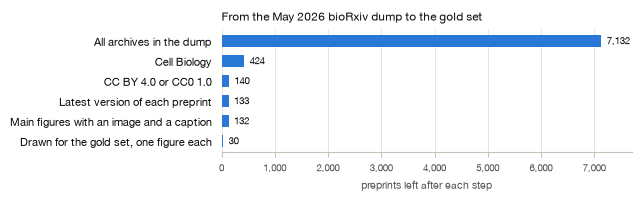

In [4]:
BLUE, INK, INK_2, GRID, AXIS = '#2a78d6', '#0b0b0b', '#52514e', '#e1e0d9', '#c3c2b7'
plt.style.use('default')   # the IDE's dark theme would otherwise leak into the saved file
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Helvetica Neue', 'Arial', 'DejaVu Sans'], 'font.size': 8,
    'text.color': INK, 'axes.edgecolor': AXIS, 'axes.labelcolor': INK_2, 'axes.labelsize': 7.5,
    'axes.titlesize': 8.5, 'axes.titlelocation': 'left', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.left': False, 'axes.grid': True, 'axes.grid.axis': 'x', 'axes.axisbelow': True,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'xtick.color': AXIS, 'xtick.labelcolor': INK_2,
    'xtick.labelsize': 7, 'ytick.left': False, 'ytick.labelcolor': INK,
    'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.facecolor': 'white',
})

y = list(range(len(funnel)))[::-1]   # first step on top
fig, ax = plt.subplots(figsize=(6.3, 1.9), layout='constrained')
ax.barh(y, funnel['preprints'], height=0.6, color=BLUE)
for yi, n in zip(y, funnel['preprints']):
    ax.annotate(f'{n:,}', (n, yi), xytext=(4, 0), textcoords='offset points', va='center', fontsize=7)
ax.set_yticks(y, funnel['step'])
ax.set_xlim(0, funnel['preprints'].max() * 1.08)
ax.xaxis.set_major_formatter('{x:,.0f}')
ax.set_xlabel('preprints left after each step')
ax.set_title('From the May 2026 bioRxiv dump to the gold set')
fig.savefig(GOLD_DIR / 'sampling_funnel.png')
plt.show()

## 3. Get 30 figures

Uses Python's `random.Random` with the fixed seed from the setup cell.

In [5]:
def short_authors(surnames):
    """Author credit"""
    return f'{surnames[0]} et al.' if len(surnames) > 2 else ' and '.join(surnames)


rng = random.Random(SEED)
by_preprint = pool.set_index('preprint')
sample = []
for preprint in rng.sample(sorted(by_preprint.index), SAMPLE_SIZE):
    article = by_preprint.loc[preprint]
    figure = rng.choice(article['main'])
    sample.append({
        'key': f"{preprint}v{article['version']}_{figure['fig_id']}",
        'archive': article['archive'],
        'preprint': f"{preprint}v{article['version']}",
        'doi': article['doi'],
        'title': article['title'],
        'authors': short_authors(article['surnames']),
        'licence': article['licence'],
        'licence_url': article['licence_url'],
        'fig_id': figure['fig_id'],
        'figure_label': figure['label'],
        'caption': figure['caption'],
        'href': figure['href'],
    })
sample.sort(key=lambda s: s['key'])

print(pd.Series([s['licence'] for s in sample]).value_counts().to_string())
pd.DataFrame(sample)[['key', 'figure_label', 'licence', 'authors', 'title']]

CC BY 4.0    28
CC0 1.0       2


,key,figure_label,licence,authors,title
0,619578v3_fig3,Figure 3.,CC BY 4.0,Tittelmeier et al.,Disruption of sphingolipid metabolism promotes...
1,628646v3_fig2,Figure 2.,CC BY 4.0,Edwards et al.,ABHD2 activity is not required for the non-gen...
2,638155v5_fig1,Fig 1.,CC BY 4.0,Iuchi and Paulo,"The roles of MKI67, GNL2, and MDN1 in Ribosome..."
3,645038v6_fig5,Figure 5.,CC BY 4.0,Fuller et al.,ATG2A interacts with RAB1A and ARFGAP1 positiv...
4,667258v2_fig11,Fig 11:,CC BY 4.0,Same-Majandeh et al.,A Dynamic Model of Calcium Frequency Modulatio...
5,716888v2_fig2,Figure 2:,CC BY 4.0,Versluis and Insall,Tell your friends: communication through autoa...
6,719914v1_fig2,Figure 2:,CC BY 4.0,Fröbel et al.,Mesenchymal stroma cell-derived stem cell fact...
7,721503v1_fig3,Figure 3:,CC0 1.0,Buglak et al.,The Nuclear Pore Complex Facilitates Centriole...
8,722203v1_fig7,Figure 7.,CC BY 4.0,Asaro et al.,Ether lipid remodeling during neuronal differe...
9,722309v1_fig3,Figure 3.,CC BY 4.0,Wu et al.,An interaction between HP1 and the Chromosomal...


## 4. Save the images and start the annotation files

```json
"gold": {"figure_type": "", "ocr_text": "", "entities": [], "notes": "", "done": false}
```


In [6]:
def save_png(archive, href, out_path):
    """Read a figure's TIFF out of its archive and save it as a PNG at full size."""
    with zipfile.ZipFile(MECA_DIR / archive) as zf:
        member = next(n for n in zf.namelist() if Path(n).name == Path(href).name)
        with Image.open(BytesIO(zf.read(member))) as img:
            img.convert('RGB').save(out_path, optimize=True)
            return img.size


def new_annotation(s):
    """The article and the caption, with the gold block still empty."""
    paper = {k: s[k] for k in ('preprint', 'doi', 'title', 'authors', 'licence', 'figure_label', 'caption')}
    gold = {'figure_type': '', 'ocr_text': '', 'entities': [], 'notes': '', 'done': False}
    return {'key': s['key'], 'paper': paper, 'gold': gold}


created = 0
for s in sample:
    s['width'], s['height'] = save_png(s['archive'], s['href'], IMAGE_DIR / f"{s['key']}.png")
    path = ANNOTATION_DIR / f"{s['key']}.json"
    if not path.exists():
        path.write_text(json.dumps(new_annotation(s), indent=2, ensure_ascii=False) + '\n', encoding='utf-8')
        created += 1

size_mb = sum((IMAGE_DIR / f"{s['key']}.png").stat().st_size for s in sample) / 1e6
print(f'{len(sample)} images saved, {size_mb:.0f} MB in total')
print(f'{created} new annotation files, {len(sample) - created} existing ones left as they were')

30 images saved, 55 MB in total
0 new annotation files, 30 existing ones left as they were


## 5. Record the sample

`gold_set/sample.json` records how the sample was drawn: the corpus fingerprint, the filters, the seed, the funnel above and the 30 figures in order. The annotation and evaluation notebooks read their list of figures from it. `gold_set/attribution.md` credits the authors of each figure, as CC BY requires.

In [7]:
manifest = {
    'corpus': 'bioRxiv monthly dump, May 2026',
    'archives': len(archives),
    'fingerprint_sha1': fingerprint,
    'subject': SUBJECT,
    'licences': list(LICENCES.values()),
    'main_figure_id': MAIN_FIGURE.pattern,
    'seed': SEED,
    'sample_size': SAMPLE_SIZE,
    'funnel': funnel.to_dict('records'),
    'figures': [{k: s[k] for k in ('key', 'preprint', 'doi', 'fig_id', 'figure_label', 'licence', 'authors',
                                   'title', 'archive', 'width', 'height')} for s in sample],
}
(GOLD_DIR / 'sample.json').write_text(json.dumps(manifest, indent=2, ensure_ascii=False) + '\n', encoding='utf-8')

lines = [
    '# Sources of the gold-set figures',
    '',
    'Every image in `images/` is a figure from the bioRxiv preprint listed next to it, saved as a PNG from the TIFF '
    'in its archive with no other change. The authors released these preprints under the licence shown. '
    'CC BY 4.0 asks for this credit and CC0 1.0 asks for none.',
    '',
    '| Image | Figure | Preprint | Authors | Licence |',
    '| --- | --- | --- | --- | --- |',
]
for s in sample:
    lines.append(f"| {s['key']}.png | Figure {s['fig_id'][3:]} | [{s['title']}](https://doi.org/{s['doi']}) "
                 f"| {s['authors']} | [{s['licence']}]({s['licence_url']}) |")
(GOLD_DIR / 'attribution.md').write_text('\n'.join(lines) + '\n', encoding='utf-8')

for name in ('sample.json', 'attribution.md'):
    print('wrote', (GOLD_DIR / name).relative_to(ROOT))

wrote gold_set/sample.json
wrote gold_set/attribution.md


## 6. Sample check



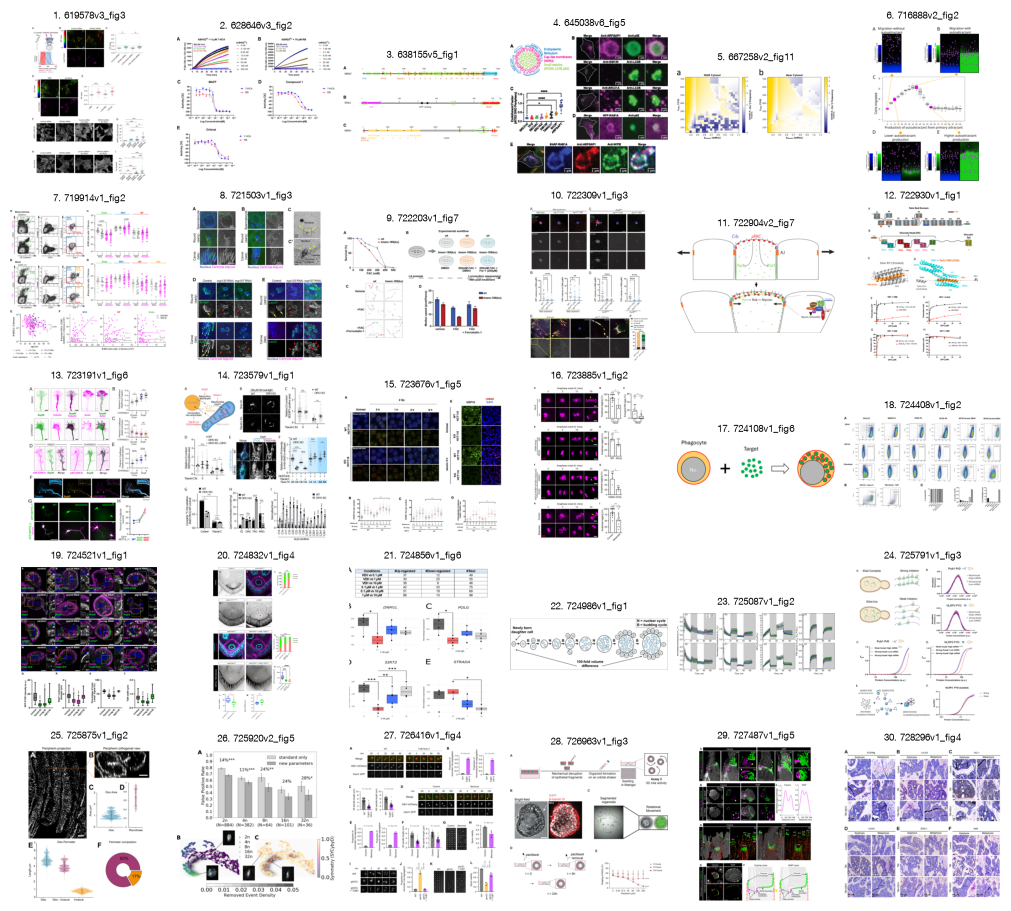

In [8]:
fig, axes = plt.subplots(5, 6, figsize=(10, 9), layout='constrained')
for i, (ax, s) in enumerate(zip(axes.flat, sample), start=1):
    with Image.open(IMAGE_DIR / f"{s['key']}.png") as img:
        img.thumbnail((400, 400))   # small copies keep the notebook light
        ax.imshow(img)
    ax.set_title(f"{i}. {s['key']}", fontsize=7, loc='center')
    ax.axis('off')
plt.show()